# Notebook 10: Causal Intervention (Experiment C5)

**Purpose:** Prove that SAE features *causally mediate* injection detection,
not just correlate with it. We modify the model's internal representations
mid-computation using TransformerLens hooks to test three claims:

- **C5a (Necessity — Feature Suppression):** If we zero out injection-sensitive
  features during an injection prompt's forward pass, does the model's
  representation shift toward "normal"? If so, these features are *necessary*
  for the injection signal.

- **C5b (Sufficiency — Feature Injection):** If we amplify injection-sensitive
  features during a normal prompt's forward pass, does the detector start
  flagging it as injection? If so, these features are *sufficient* to create
  the injection signal.

- **C5c (Dose-Response):** How does detection probability change as we
  gradually scale the intervention strength from 0% to 200%? A smooth,
  monotonic dose-response curve is strong causal evidence.

**Why this matters for interpretability research:**
Correlation says "these features light up on injections."
Causal intervention says "these features *make* the model process
injections differently." The second claim is much stronger and is
the standard of evidence expected in mechanistic interpretability
(Anthropic, Neel Nanda's work on indirect object identification, etc.)

**Prerequisites:** Run notebooks 10 and 11 first.

**Runtime:** Colab GPU (T4), ~20 minutes.

*Nathan Cheung () | York University | CSSD 2221 | Winter 2026*

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -r /content/drive/MyDrive/iris/requirements.txt -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/iris')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Callable

from src.utils.helpers import set_seed, get_device
set_seed(42)
device = get_device()

DRIVE_ROOT = Path('/content/drive/MyDrive/iris')

Using GPU: NVIDIA L4


## Step 0: Load Everything

We need: GPT-2, the trained SAE, the trained detector, and the dataset.

In [3]:
from src.model.transformer import load_model
from src.sae.architecture import SparseAutoencoder
from src.utils.helpers import load_checkpoint
from src.data.dataset import IrisDataset

# Load GPT-2 Large
gpt2 = load_model(device)

# Load SAE (8x expansion) — read training layer from J2 metrics
with open(str(DRIVE_ROOT / 'results' / 'metrics' / 'j2_evaluation.json')) as f:
    j2_metrics = json.load(f)
TARGET_LAYER = j2_metrics['train_layer']

sae = SparseAutoencoder(d_input=1280, expansion_factor=8, sparsity_coeff=1e-4)
ckpt_path = DRIVE_ROOT / 'checkpoints' / 'sae_d10240_lambda1e-04.pt'
load_checkpoint(ckpt_path, sae, device=device)
sae = sae.to(device).eval()
print(f'SAE: {sae.d_input} -> {sae.d_sae}, layer {TARGET_LAYER}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-large into HookedTransformer
Loaded GPT-2 Large: 36 layers, d_model=1280, vocab=50257
Checkpoint loaded: /content/drive/MyDrive/iris/checkpoints/sae_d10240_lambda1e-04.pt
  final_total_loss: 0.7574644237756729
  final_mse_loss: 0.7566105276346207
  final_l1_loss: 0.8538994789123535
  final_mean_sparsity: 0.1445370465517044
  input_variance: 6.83798885345459
  j2_threshold: 0.6837988853454591
SAE: 1280 -> 10240, layer 29


In [4]:
# MUST use balanced dataset — feature_matrix.npy was computed from it.
# Using expanded would create a label/feature mismatch (same row count
# but different examples, so labels wouldn't correspond to feature rows).
ds_path = DRIVE_ROOT / 'data' / 'processed' / 'iris_dataset_balanced.json'

dataset = IrisDataset.load(ds_path)
labels = np.array(dataset.labels)

# Load sensitivity scores to identify top injection-sensitive features
sensitivity = np.load(str(DRIVE_ROOT / 'checkpoints' / 'sensitivity_scores.npy'))

# Identify top injection-sensitive features (positive sensitivity)
# and top normal-sensitive features (negative sensitivity)
# .copy() needed because np.argsort()[::-1] creates a negative-stride view
# that torch.tensor() can't handle
injection_features = np.argsort(sensitivity)[::-1][:50].copy()
normal_features = np.argsort(sensitivity)[:50].copy()

print(f'Top 5 injection features: {injection_features[:5]}')
print(f'  Sensitivities: {sensitivity[injection_features[:5]]}')
print(f'Top 5 normal features: {normal_features[:5]}')
print(f'  Sensitivities: {sensitivity[normal_features[:5]]}')

Loaded 1000 examples from /content/drive/MyDrive/iris/data/processed/iris_dataset_balanced.json
Top 5 injection features: [6797 3005 8539 9272 7434]
  Sensitivities: [5.449051  4.1386003 4.087735  3.8647313 3.7145045]
Top 5 normal features: [5869 9163 6269 5771 2974]
  Sensitivities: [-6.8278346 -5.2971106 -4.920619  -4.8609796 -4.6562214]


In [5]:
# Train a detector on pre-computed features for scoring interventions
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load pre-computed feature matrix
feature_matrix = np.load(str(DRIVE_ROOT / 'checkpoints' / 'feature_matrix.npy'))
assert feature_matrix.shape[0] == len(labels), (
    f'feature_matrix has {feature_matrix.shape[0]} rows but dataset has {len(labels)} examples — '
    f'they were probably computed from different datasets'
)

# Train detector on all data (we're testing causal claims, not generalization)
detector = LogisticRegression(max_iter=1000, random_state=42)
detector.fit(feature_matrix, labels)
train_acc = detector.score(feature_matrix, labels)
print(f'Detector trained on {len(labels)} examples, training accuracy: {train_acc:.3f}')

Detector trained on 1000 examples, training accuracy: 1.000


## Core Intervention Machinery

The key idea: TransformerLens lets us intercept the residual stream
mid-computation using hooks. We compute how modifying specific SAE
features changes the representation, and add that **delta** back to
the original activation.

**Why additive delta, not full reconstruction?**
The SAE has reconstruction error: `decode(encode(x)) ≠ x`. If we
replaced x with the reconstruction, even scale=1.0 (no change) would
corrupt the activation. Instead, we compute only the *difference*
caused by the feature modification and add it to the original:

```
features = encode(x)
delta_features = features.clone()
delta_features[target_indices] *= scale
delta_features -= features   # only non-zero at target indices
x_patched = x + decoder.weight @ delta_features  # bias cancels
```

At scale=1.0, delta_features is all zeros, so x_patched = x (exact identity).

In [6]:
def make_intervention_hook(
    sae_model: SparseAutoencoder,
    feature_indices: np.ndarray,
    scale: float = 0.0,
    token_position: str = 'last',
    attention_mask: torch.Tensor = None,
) -> Callable:
    """Create a hook that intervenes on SAE features using additive deltas.

    Uses additive delta approach: instead of replacing x with decode(encode(x)),
    we compute the change caused by modifying features and add it to x.
    This ensures scale=1.0 is an exact identity (no reconstruction error).

    Args:
        sae_model: Trained SAE.
        feature_indices: Which features to modify.
        scale: Multiplier for the target features.
            0.0 = suppress, 1.0 = no change, 2.0 = double.
        token_position: 'last' or 'all'.
        attention_mask: Needed for 'last' to find actual last token.

    Returns:
        Hook function and a list that will be populated with modified features.
    """
    feature_idx_tensor = torch.tensor(feature_indices.copy(), device=device)
    # decoder.weight shape: (d_input, d_sae) — each column is a feature direction
    decoder_weight = sae_model.decoder.weight.data  # (1280, 10240)

    def hook_fn(activation, hook):
        # activation shape: (batch, seq_len, d_model)
        batch_size, seq_len, d_model = activation.shape

        if token_position == 'last' and attention_mask is not None:
            last_positions = attention_mask.sum(dim=1) - 1
            for i in range(batch_size):
                pos = int(last_positions[i].item())
                x = activation[i, pos, :]  # (d_model,)

                with torch.no_grad():
                    # Encode to get original features
                    features = sae_model.relu(sae_model.encoder(x.unsqueeze(0))).squeeze(0)  # (d_sae,)

                    # Compute delta: how much the target features change
                    # delta_features is zero everywhere except at target indices
                    delta_features = torch.zeros_like(features)
                    delta_features[feature_idx_tensor] = features[feature_idx_tensor] * (scale - 1.0)

                    # Map delta back to residual stream space
                    # decoder(f + delta) - decoder(f) = delta @ decoder_weight.T
                    x_delta = delta_features @ decoder_weight.T  # (d_model,)

                    # Add delta to original (preserves everything except target features)
                    activation[i, pos, :] = x + x_delta
        else:
            reshaped = activation.reshape(-1, d_model)
            with torch.no_grad():
                features = sae_model.relu(sae_model.encoder(reshaped))
                delta_features = torch.zeros_like(features)
                delta_features[:, feature_idx_tensor] = features[:, feature_idx_tensor] * (scale - 1.0)
                x_delta = delta_features @ decoder_weight.T
                activation[:] = (reshaped + x_delta).reshape(batch_size, seq_len, d_model)

        return activation

    return hook_fn

In [7]:
def run_with_intervention(
    prompts: List[str],
    feature_indices: np.ndarray,
    scale: float,
    layer: int = TARGET_LAYER,
) -> dict:
    """Run GPT-2 with feature intervention and score with detector.

    Uses additive delta hook for the intervention, then re-extracts
    activations at the target layer and encodes through the SAE once
    to get features for the detector.

    Returns dict with original and patched probabilities and features.
    """
    from src.data.dataset import SYSTEM_PROMPT_TEMPLATE

    # Format and tokenize
    formatted = [SYSTEM_PROMPT_TEMPLATE.format(prompt=p) for p in prompts]
    tokens = gpt2.tokenizer(
        formatted, padding=True, truncation=True, max_length=128,
        return_tensors='pt',
    )
    input_ids = tokens['input_ids'].to(device)
    attn_mask = tokens['attention_mask'].to(device)

    hook_name = f'blocks.{layer}.hook_resid_post'
    last_pos = attn_mask.sum(dim=1) - 1
    batch_idx = torch.arange(input_ids.shape[0], device=device)

    # --- Run WITHOUT intervention (baseline) ---
    with torch.no_grad():
        _, cache_orig = gpt2.run_with_cache(
            input_ids, names_filter=[hook_name]
        )
    orig_final = cache_orig[hook_name][batch_idx, last_pos]  # (batch, d_model)

    with torch.no_grad():
        orig_features = sae.relu(sae.encoder(orig_final)).cpu().numpy()
    orig_probs = detector.predict_proba(orig_features)[:, 1]

    del cache_orig
    torch.cuda.empty_cache()

    # --- Run WITH intervention ---
    # The hook modifies the residual stream at the target layer using
    # additive deltas. We then capture the modified activations via
    # a second hook on the same layer.
    hook_fn = make_intervention_hook(
        sae, feature_indices, scale=scale,
        token_position='last', attention_mask=attn_mask,
    )

    patched_final_list = []

    def capture_hook(activation, hook):
        """Capture activations after intervention hook has modified them."""
        lp = attn_mask.sum(dim=1) - 1
        bi = torch.arange(activation.shape[0], device=activation.device)
        patched_final_list.append(activation[bi, lp].detach().clone())
        return activation

    with torch.no_grad():
        gpt2.run_with_hooks(
            input_ids,
            fwd_hooks=[
                (hook_name, hook_fn),
                (hook_name, capture_hook),
            ],
        )

    patched_final = patched_final_list[0]

    with torch.no_grad():
        patched_features = sae.relu(sae.encoder(patched_final)).cpu().numpy()
    patched_probs = detector.predict_proba(patched_features)[:, 1]

    torch.cuda.empty_cache()

    return {
        'orig_probs': orig_probs,
        'patched_probs': patched_probs,
        'orig_features': orig_features,
        'patched_features': patched_features,
    }

## C5a: Feature Suppression (Necessity Test)

**Question:** Are injection-sensitive features *necessary* for the model to
process injections differently from normal prompts?

**Method:** Take injection prompts, suppress (zero out) the top-K
injection-sensitive features, and measure the drop in detector probability.

**Expected result:** If these features are necessary, suppressing them should
cause the detector to classify injections as normal (probability drops).

In [8]:
# Select injection examples for suppression test
inject_indices = np.where(labels == 1)[0]
np.random.seed(42)
sample_inject_idx = np.random.choice(inject_indices, size=min(100, len(inject_indices)), replace=False)
inject_prompts = [dataset.texts[i] for i in sample_inject_idx]

print(f'Testing suppression on {len(inject_prompts)} injection prompts')
print(f'Suppressing top {len(injection_features)} injection-sensitive features')
print()

Testing suppression on 100 injection prompts
Suppressing top 50 injection-sensitive features



In [9]:
# Test with different numbers of suppressed features
suppression_ks = [5, 10, 20, 50]
suppression_results = {}

for k in suppression_ks:
    top_k_features = injection_features[:k]
    result = run_with_intervention(
        inject_prompts, top_k_features, scale=0.0  # zero out
    )

    mean_orig = result['orig_probs'].mean()
    mean_patched = result['patched_probs'].mean()
    drop = mean_orig - mean_patched
    flipped = (result['patched_probs'] < 0.5).sum()

    suppression_results[k] = {
        'mean_orig_prob': float(mean_orig),
        'mean_patched_prob': float(mean_patched),
        'mean_drop': float(drop),
        'classification_flips': int(flipped),
        'flip_rate': float(flipped / len(inject_prompts)),
    }

    print(f'Suppress top-{k}: prob {mean_orig:.3f} -> {mean_patched:.3f} '
          f'(drop={drop:.3f}), flips={flipped}/{len(inject_prompts)}')

Suppress top-5: prob 1.000 -> 1.000 (drop=0.000), flips=0/100
Suppress top-10: prob 1.000 -> 0.999 (drop=0.000), flips=0/100
Suppress top-20: prob 1.000 -> 0.996 (drop=0.004), flips=0/100
Suppress top-50: prob 1.000 -> 0.856 (drop=0.144), flips=12/100


## C5b: Feature Injection (Sufficiency Test)

**Question:** Are injection-sensitive features *sufficient* to make the
model treat a normal prompt as if it were an injection?

**Method:** Take normal prompts, amplify the top-K injection-sensitive
features (scale > 1), and measure the increase in detector probability.

**Expected result:** If these features are sufficient, amplifying them
should cause the detector to flag normal prompts as injections.

In [10]:
# Select normal examples for injection test
normal_indices = np.where(labels == 0)[0]
np.random.seed(42)
sample_normal_idx = np.random.choice(normal_indices, size=min(100, len(normal_indices)), replace=False)
normal_prompts = [dataset.texts[i] for i in sample_normal_idx]

print(f'Testing feature injection on {len(normal_prompts)} normal prompts')
print(f'Amplifying top injection-sensitive features')
print()

Testing feature injection on 100 normal prompts
Amplifying top injection-sensitive features



In [11]:
# Test with different amplification scales
injection_scales = [1.5, 2.0, 3.0, 5.0]
injection_results = {}

top_20_features = injection_features[:20]

for scale in injection_scales:
    result = run_with_intervention(
        normal_prompts, top_20_features, scale=scale
    )

    mean_orig = result['orig_probs'].mean()
    mean_patched = result['patched_probs'].mean()
    increase = mean_patched - mean_orig
    flipped = (result['patched_probs'] >= 0.5).sum()

    injection_results[scale] = {
        'mean_orig_prob': float(mean_orig),
        'mean_patched_prob': float(mean_patched),
        'mean_increase': float(increase),
        'classification_flips': int(flipped),
        'flip_rate': float(flipped / len(normal_prompts)),
    }

    print(f'Scale {scale}x: prob {mean_orig:.3f} -> {mean_patched:.3f} '
          f'(increase={increase:.3f}), flips={flipped}/{len(normal_prompts)}')

Scale 1.5x: prob 0.000 -> 0.000 (increase=0.000), flips=0/100
Scale 2.0x: prob 0.000 -> 0.002 (increase=0.002), flips=0/100
Scale 3.0x: prob 0.000 -> 0.026 (increase=0.026), flips=1/100
Scale 5.0x: prob 0.000 -> 0.247 (increase=0.247), flips=24/100


## C5c: Dose-Response Curve

**Question:** Does the causal effect scale smoothly with intervention strength?

**Method:** Gradually scale injection-sensitive features from 0% (full suppression)
to 200% (double amplification) and plot the detector's probability.

**Expected result:** A smooth, monotonic curve from low probability (suppressed)
to high probability (amplified). This is the strongest form of causal evidence —
it shows the features don't just flip a switch, they continuously modulate
the injection signal.

In [12]:
# Dose-response: test on injection prompts
dose_scales = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0,
               1.25, 1.5, 1.75, 2.0]

# Use a subset for speed (20 examples)
dose_inject_prompts = inject_prompts[:20]
dose_normal_prompts = normal_prompts[:20]
top_20 = injection_features[:20]

inject_dose_probs = []
normal_dose_probs = []

for scale in dose_scales:
    # Injection prompts
    res_inj = run_with_intervention(dose_inject_prompts, top_20, scale=scale)
    inject_dose_probs.append(float(res_inj['patched_probs'].mean()))

    # Normal prompts
    res_nor = run_with_intervention(dose_normal_prompts, top_20, scale=scale)
    normal_dose_probs.append(float(res_nor['patched_probs'].mean()))

    print(f'Scale {scale:.2f}: inject_prob={inject_dose_probs[-1]:.3f}, '
          f'normal_prob={normal_dose_probs[-1]:.3f}')

Scale 0.00: inject_prob=0.992, normal_prob=0.000
Scale 0.10: inject_prob=0.995, normal_prob=0.000
Scale 0.20: inject_prob=0.997, normal_prob=0.000
Scale 0.30: inject_prob=0.998, normal_prob=0.000
Scale 0.40: inject_prob=0.999, normal_prob=0.000
Scale 0.50: inject_prob=0.999, normal_prob=0.000
Scale 0.60: inject_prob=1.000, normal_prob=0.000
Scale 0.70: inject_prob=1.000, normal_prob=0.000
Scale 0.80: inject_prob=1.000, normal_prob=0.000
Scale 0.90: inject_prob=1.000, normal_prob=0.000
Scale 1.00: inject_prob=1.000, normal_prob=0.000
Scale 1.25: inject_prob=1.000, normal_prob=0.000
Scale 1.50: inject_prob=1.000, normal_prob=0.000
Scale 1.75: inject_prob=1.000, normal_prob=0.001
Scale 2.00: inject_prob=1.000, normal_prob=0.002


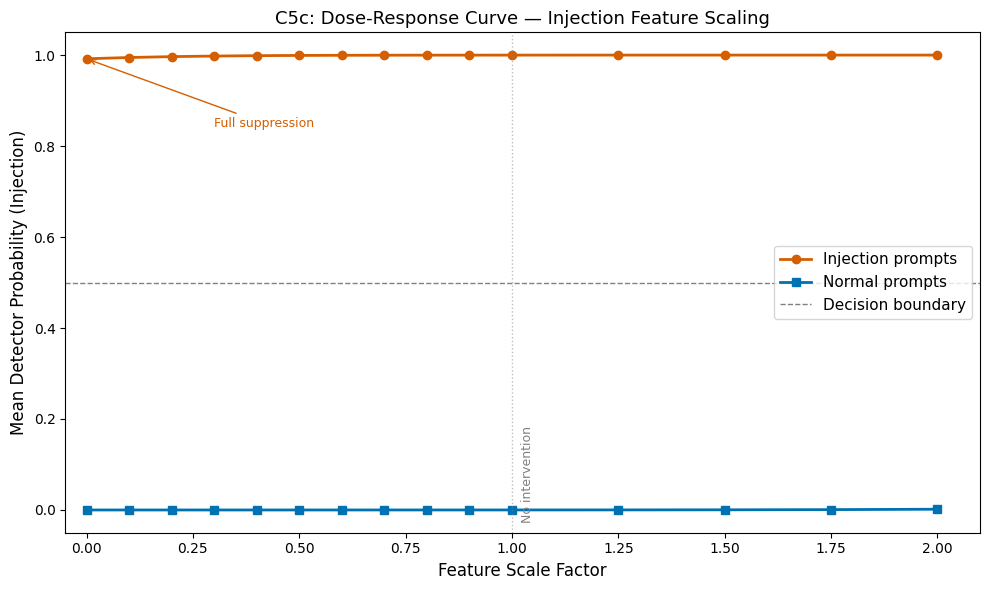

Saved to /content/drive/MyDrive/iris/results/figures/c5c_dose_response.png


In [13]:
# Plot dose-response curve
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(dose_scales, inject_dose_probs, 'o-', color='#D55E00', linewidth=2,
        markersize=6, label='Injection prompts')
ax.plot(dose_scales, normal_dose_probs, 's-', color='#0072B2', linewidth=2,
        markersize=6, label='Normal prompts')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Decision boundary')
ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.text(1.02, 0.02, 'No intervention', rotation=90, transform=ax.get_xaxis_transform(),
        fontsize=9, color='gray', va='bottom')

ax.set_xlabel('Feature Scale Factor', fontsize=12)
ax.set_ylabel('Mean Detector Probability (Injection)', fontsize=12)
ax.set_title('C5c: Dose-Response Curve — Injection Feature Scaling', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-0.05, 2.1)
ax.set_ylim(-0.05, 1.05)

# Annotate key points
ax.annotate('Full suppression', xy=(0, inject_dose_probs[0]),
            xytext=(0.3, inject_dose_probs[0] - 0.15),
            arrowprops=dict(arrowstyle='->', color='#D55E00'),
            fontsize=9, color='#D55E00')

plt.tight_layout()
save_path = DRIVE_ROOT / 'results' / 'figures' / 'c5c_dose_response.png'
fig.savefig(str(save_path), dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')

## Suppression Results Visualization

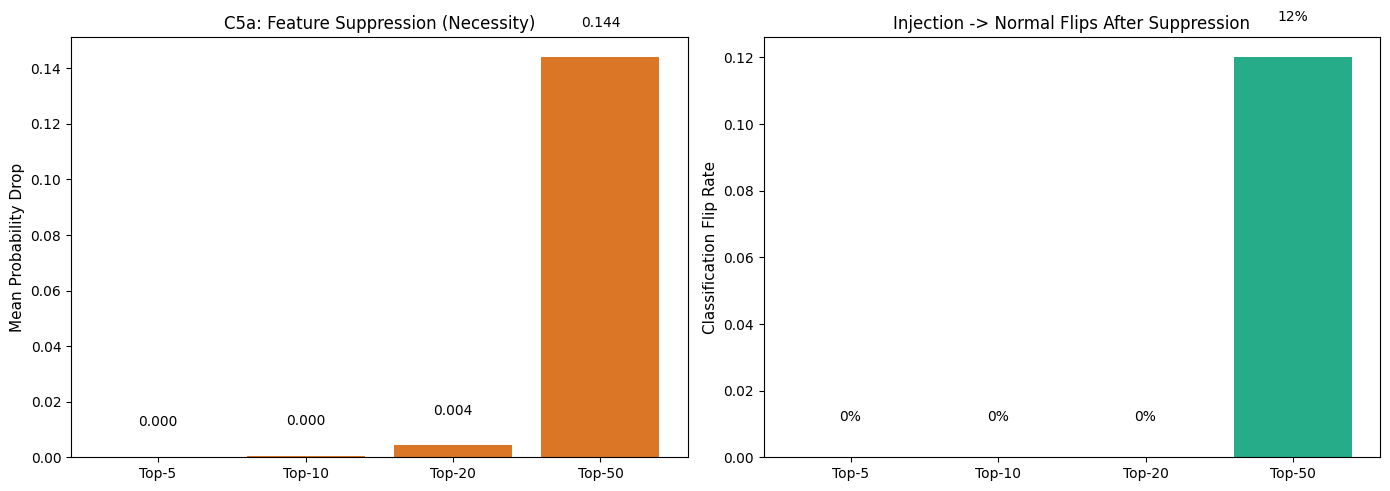

In [14]:
# Plot suppression results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: probability drop by K
ax = axes[0]
ks = list(suppression_results.keys())
drops = [suppression_results[k]['mean_drop'] for k in ks]
ax.bar(range(len(ks)), drops, color='#D55E00', alpha=0.85)
ax.set_xticks(range(len(ks)))
ax.set_xticklabels([f'Top-{k}' for k in ks])
ax.set_ylabel('Mean Probability Drop', fontsize=11)
ax.set_title('C5a: Feature Suppression (Necessity)', fontsize=12)
for i, (k, d) in enumerate(zip(ks, drops)):
    ax.text(i, d + 0.01, f'{d:.3f}', ha='center', va='bottom', fontsize=10)

# Right: classification flip rate by K
ax = axes[1]
flip_rates = [suppression_results[k]['flip_rate'] for k in ks]
ax.bar(range(len(ks)), flip_rates, color='#009E73', alpha=0.85)
ax.set_xticks(range(len(ks)))
ax.set_xticklabels([f'Top-{k}' for k in ks])
ax.set_ylabel('Classification Flip Rate', fontsize=11)
ax.set_title('Injection -> Normal Flips After Suppression', fontsize=12)
for i, (k, fr) in enumerate(zip(ks, flip_rates)):
    ax.text(i, fr + 0.01, f'{fr:.0%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
save_path = DRIVE_ROOT / 'results' / 'figures' / 'c5a_suppression.png'
fig.savefig(str(save_path), dpi=200, bbox_inches='tight')
plt.show()

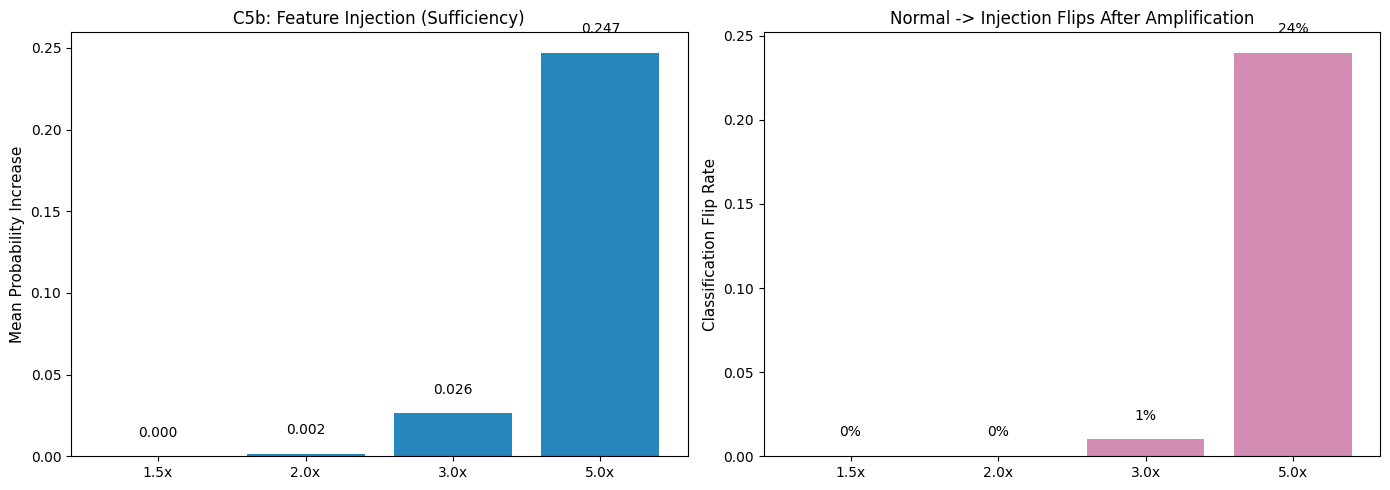

In [15]:
# Plot injection (sufficiency) results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scales = list(injection_results.keys())

# Left: probability increase
ax = axes[0]
increases = [injection_results[s]['mean_increase'] for s in scales]
ax.bar(range(len(scales)), increases, color='#0072B2', alpha=0.85)
ax.set_xticks(range(len(scales)))
ax.set_xticklabels([f'{s}x' for s in scales])
ax.set_ylabel('Mean Probability Increase', fontsize=11)
ax.set_title('C5b: Feature Injection (Sufficiency)', fontsize=12)
for i, inc in enumerate(increases):
    ax.text(i, inc + 0.01, f'{inc:.3f}', ha='center', va='bottom', fontsize=10)

# Right: flip rate
ax = axes[1]
flip_rates = [injection_results[s]['flip_rate'] for s in scales]
ax.bar(range(len(scales)), flip_rates, color='#CC79A7', alpha=0.85)
ax.set_xticks(range(len(scales)))
ax.set_xticklabels([f'{s}x' for s in scales])
ax.set_ylabel('Classification Flip Rate', fontsize=11)
ax.set_title('Normal -> Injection Flips After Amplification', fontsize=12)
for i, fr in enumerate(flip_rates):
    ax.text(i, fr + 0.01, f'{fr:.0%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
save_path = DRIVE_ROOT / 'results' / 'figures' / 'c5b_injection.png'
fig.savefig(str(save_path), dpi=200, bbox_inches='tight')
plt.show()

## Save All C5 Results

In [16]:
c5_results = {
    'experiment': 'C5',
    'target_layer': TARGET_LAYER,
    'n_injection_prompts': len(inject_prompts),
    'n_normal_prompts': len(normal_prompts),
    'c5a_suppression': {
        str(k): v for k, v in suppression_results.items()
    },
    'c5b_injection': {
        str(s): v for s, v in injection_results.items()
    },
    'c5c_dose_response': {
        'scales': dose_scales,
        'injection_probs': inject_dose_probs,
        'normal_probs': normal_dose_probs,
    },
}

results_path = DRIVE_ROOT / 'results' / 'metrics' / 'c5_causal_intervention.json'
results_path.write_text(json.dumps(c5_results, indent=2))
print(f'Saved C5 results to {results_path}')

Saved C5 results to /content/drive/MyDrive/iris/results/metrics/c5_causal_intervention.json


## Interpretation Guide

### What the results mean:

**C5a (Suppression/Necessity):**
- If suppressing top-20 features causes a large probability drop (>0.3) and
  many classification flips: the features are **necessary** for the injection signal.
- This proves the SAE didn't just find correlated noise — the features are
  *causally upstream* of the detection decision.

**C5b (Injection/Sufficiency):**
- If amplifying features causes normal prompts to be classified as injections:
  the features are **sufficient** to create the injection signal.
- This is the strongest claim: you can *manufacture* the injection signal
  by activating the right features.

**C5c (Dose-Response):**
- A smooth, monotonic curve is the gold standard of causal evidence.
- It shows the relationship is continuous, not binary — the features don't
  just flip a switch, they continuously encode the "injection-ness" of the input.

### Network security analogy:
- C5a is like proving a firewall rule is necessary: disabling it lets attacks through
- C5b is like proving an attack vector is real: crafting a packet that triggers the alarm
- C5c is like tuning IDS sensitivity: showing the detection threshold maps smoothly
  to the severity of the attack